# Logistic Regression: Comprehensive Guide & Implementation
---

## 1. What is Logistic Regression?

Logistic Regression is a supervised machine learning algorithm used to predict the **probability** of a categorical dependent variable. 

* **Binary Classification:** The target variable has two discrete outcomes ($0$ or $1$, True or False, Yes or No).
* **Core Output:** Instead of fitting a straight line through data points, it outputs a probability score between $0.0$ and $1.0$.

---

## 2. Why Linear Regression Fails for Classification

Trying to use Linear Regression for classification introduces two major mathematical flaws:
1. **Unbounded Predictions:** Linear regression lines can stretch from $-\infty$ to $+\infty$, whereas probabilities must be strictly bounded between $0$ and $1$ (0% to 100%).
2. **Outlier Sensitivity:** Extreme outliers can tilt a linear regression line heavily, breaking the threshold boundary required to separate classes accurately.

---

## 3. The Core Mechanics: The Sigmoid Function

To constrain outputs between $0$ and $1$, Logistic Regression applies the **Sigmoid (Logistic) Function** to a linear equation:

$$P = \frac{1}{1 + e^{-z}}$$

Where $z$ is the standard linear combination of features:

$$z = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots + \beta_nx_n$$

### Decision Boundary & Threshold
Once the sigmoid function outputs a probability $P$:
* If $P \ge 0.5$ $\rightarrow$ Predict **Class 1** (e.g., Refunded / Canceled).
* If $P < 0.5$ $\rightarrow$ Predict **Class 0** (e.g., Completed Order).

---

## 4. Cost Function: Log Loss (Binary Cross-Entropy)

Unlike Linear Regression which uses Mean Squared Error (MSE), Logistic Regression uses **Log Loss** to prevent non-convex error surfaces. 

* **Penalty System:** It heavily penalizes confident wrong predictions (e.g., model predicts 99% certainty for a class, but the actual label is opposite), forcing gradient descent to adjust weights effectively.

---


**Import Liberaries**

In [80]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import f1_score, recall_score, accuracy_score, precision_score,confusion_matrix, classification_report,ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split


*Read Data*

In [81]:
df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")
print("Success! Data loaded.")
df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_18356\1530099147.py:1: DtypeWarning: Columns (0: coupon_code, 1: additional) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")


Success! Data loaded.


,id,old_order_id,increment_id,status,channel_name,is_guest,customer_email,customer_first_name,customer_last_name,shipping_method,...,additional,tabby_payment_id,tabby_order_status,paymob_intention_id,paymob_cents_amount,tamara_order_id,tamara_checkout_id,cko_hpp_id,cko_payment_id,cko_session_id
0,1,NaN,ORD-00000001,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,ORD-00000002,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,ORD-00000003,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,ORD-00000004,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,ORD-00000005,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# EDA

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 146201 entries, 0 to 146200
Data columns (total 85 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             146201 non-null  int64  
 1   old_order_id                   23913 non-null   float64
 2   increment_id                   146201 non-null  str    
 3   status                         146201 non-null  str    
 4   channel_name                   146201 non-null  str    
 5   is_guest                       146201 non-null  int64  
 6   customer_email                 134010 non-null  str    
 7   customer_first_name            136057 non-null  str    
 8   customer_last_name             74428 non-null   str    
 9   shipping_method                75149 non-null   str    
 10  shipping_title                 75149 non-null   str    
 11  shipping_description           75149 non-null   str    
 12  coupon_code                    13444 non-

In [83]:
df.describe()

,id,old_order_id,is_guest,is_gift,total_item_count,total_qty_ordered,grand_total,cashback_opt_in,cashback_earned,base_grand_total,...,cashback,tabby_payment_id,tabby_order_status,paymob_intention_id,paymob_cents_amount,tamara_order_id,tamara_checkout_id,cko_hpp_id,cko_payment_id,cko_session_id
count,1.462010e+05,2.391300e+04,146201.0,146201.000000,146201.000000,146201.000000,146201.000000,146201.000000,146201.000000,146201.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,7.668132e+08,3.104356e+06,0.0,0.359512,1.222481,1.397713,1123.514495,0.020725,0.307358,1126.128750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,4.257860e+08,5.378918e+04,0.0,0.479859,0.825899,1.778782,2207.205445,0.142462,3.762055,2207.333091,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000e+00,1.618874e+06,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.200000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.003187e+09,3.067517e+06,0.0,0.000000,1.000000,1.000000,135.500000,0.000000,0.000000,138.900000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.003224e+09,3.109158e+06,0.0,0.000000,1.000000,1.000000,552.000000,0.000000,0.000000,556.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.003262e+09,3.146486e+06,0.0,1.000000,1.000000,1.000000,1612.000000,0.000000,0.000000,1612.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,1.003299e+09,3.184983e+06,0.0,1.000000,50.000000,200.000000,454000.000000,1.000000,100.000000,454000.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Data Preprocessing and Cleaning:**

In [84]:
df.isnull().sum()/len(df) * 100




id                      0.000000
old_order_id           83.643751
increment_id            0.000000
status                  0.000000
channel_name            0.000000
                         ...    
tamara_order_id       100.000000
tamara_checkout_id    100.000000
cko_hpp_id            100.000000
cko_payment_id        100.000000
cko_session_id        100.000000
Length: 85, dtype: float64

In [85]:
df.drop(columns=["cashback", "tabby_payment_id", "tabby_order_status", 
                 "paymob_intention_id", "paymob_cents_amount", 
                 "tamara_order_id", "tamara_checkout_id", 
                 "cko_hpp_id", "cko_payment_id", "cko_session_id"], inplace=True)


In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 146201 entries, 0 to 146200
Data columns (total 75 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             146201 non-null  int64  
 1   old_order_id                   23913 non-null   float64
 2   increment_id                   146201 non-null  str    
 3   status                         146201 non-null  str    
 4   channel_name                   146201 non-null  str    
 5   is_guest                       146201 non-null  int64  
 6   customer_email                 134010 non-null  str    
 7   customer_first_name            136057 non-null  str    
 8   customer_last_name             74428 non-null   str    
 9   shipping_method                75149 non-null   str    
 10  shipping_title                 75149 non-null   str    
 11  shipping_description           75149 non-null   str    
 12  coupon_code                    13444 non-

In [87]:
cols_to_drop = [col for col in df.columns if df[col].isnull().sum()/len(df) > 0.5]
df.drop(columns=cols_to_drop, inplace=True)

print("Dropped columns:", cols_to_drop)


Dropped columns: ['old_order_id', 'coupon_code', 'applied_cart_rule_ids']


In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 146201 entries, 0 to 146200
Data columns (total 72 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             146201 non-null  int64  
 1   increment_id                   146201 non-null  str    
 2   status                         146201 non-null  str    
 3   channel_name                   146201 non-null  str    
 4   is_guest                       146201 non-null  int64  
 5   customer_email                 134010 non-null  str    
 6   customer_first_name            136057 non-null  str    
 7   customer_last_name             74428 non-null   str    
 8   shipping_method                75149 non-null   str    
 9   shipping_title                 75149 non-null   str    
 10  shipping_description           75149 non-null   str    
 11  is_gift                        146201 non-null  int64  
 12  total_item_count               146201 non

### Drop the column which is not necessry for logistic fregression

In [89]:
cols_to_drop = [
    'id', 'increment_id', 'customer_id', 'cart_id', 
    'customer_email', 'customer_first_name', 'customer_last_name', 
    'created_at', 'updated_at', 'additional'
]
df_cleaned = df.drop(columns=cols_to_drop, errors='ignore')

**Categorical Column & Filled with Missing values** 

In [90]:
categorical_cols = df_cleaned.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].fillna('Unknown')

numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    median_val = df_cleaned[col].median()
    df_cleaned[col] = df_cleaned[col].fillna(median_val)



In [91]:
print(df_cleaned.isnull().sum())


status             0
channel_name       0
is_guest           0
shipping_method    0
shipping_title     0
                  ..
cod_charges        0
mgmt_fee           0
customer_type      0
channel_id         0
channel_type       0
Length: 62, dtype: int64


### *Encoding*

In [92]:
target_column = 'is_gift'
y = df_cleaned[target_column]
X = df_cleaned.drop(columns=cols_to_drop, errors='ignore')
X = pd.get_dummies(X, drop_first=True)


### Model 

In [93]:
model = LogisticRegression()

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
print('Training features shape:', X_train.shape)
print('Testing features shape:', X_test.shape)

Training features shape: (116960, 83)
Testing features shape: (29241, 83)


c:\Users\hp\Desktop\Machine_Learning\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Model evaluation

In [95]:
print("F1 Score:", f1_score(y_test, model.predict(X_test)))
print("Recall Score:", recall_score(y_test, model.predict(X_test)))
print("Accuracy Score:", accuracy_score(y_test, model.predict(X_test)))
print("Precision Score:", precision_score(y_test, model.predict(X_test)))
print("Confusion Matrix:\n", confusion_matrix(y_test, model.predict(X_test)))
print("Classification Report:\n", classification_report(y_test, model.predict(X_test)))
print("Model Coefficients:", model.coef_)

F1 Score: 0.9884074496389206
Recall Score: 0.9893475366178429
Accuracy Score: 0.9916555521356999
Precision Score: 0.9874691475223087
Confusion Matrix:
 [[18595   132]
 [  112 10402]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     18727
           1       0.99      0.99      0.99     10514

    accuracy                           0.99     29241
   macro avg       0.99      0.99      0.99     29241
weighted avg       0.99      0.99      0.99     29241

Model Coefficients: [[ 0.00000000e+00  1.92237866e-01  1.47232841e-01  2.08442922e-01
   3.34865395e-01  1.20250162e-03 -7.83529071e-03  2.26684675e-01
  -1.72970598e-01 -1.72367178e-01 -1.78083154e-01 -1.67624948e-03
  -1.67604106e-03 -2.91014744e-01 -2.91014744e-01  1.72421209e-01
   1.72421209e-01  4.04524775e-03  4.04524775e-03 -7.75289718e-02
   0.00000000e+00  1.74058029e-02  1.74084178e-02  7.86184444e-02
   7.86191760e-02 -3.70362325e-03 -3.70362325e-03 

<Axes: >

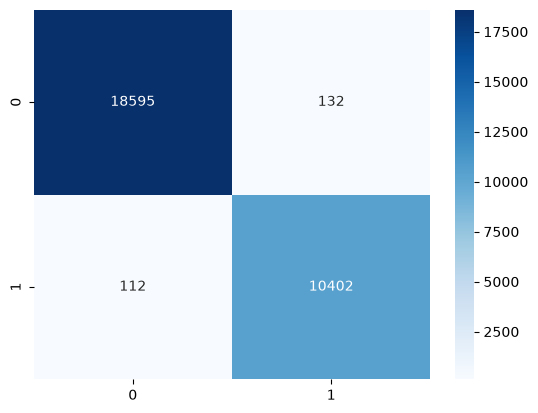

In [96]:
sns.heatmap(confusion_matrix(y_test, model.predict(X_test)), annot=True, fmt='d', cmap='Blues')

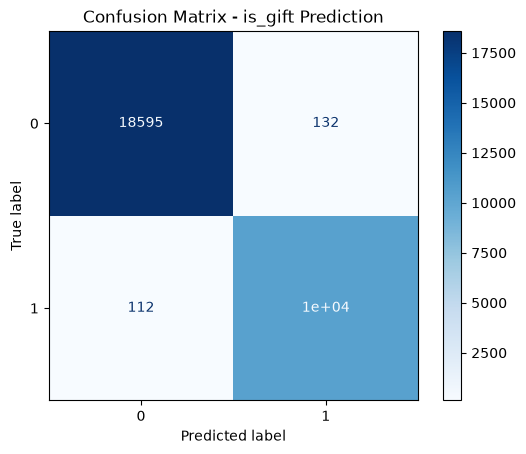

In [97]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# 2. Graph ki shakal mein plot karein
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=model.classes_
)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - is_gift Prediction')
plt.show()

In [98]:
print(y_train.value_counts(normalize=True))

is_gift
0    0.640501
1    0.359499
Name: proportion, dtype: float64


In [100]:
# X_test mein se pehli row (aik order) utha lein
sample_row = X_test.iloc[[0]]
actual_label = y_test.iloc[0]

# Model se prediction karwayen
predicted_label = model.predict(sample_row)
prediction_probability = model.predict_proba(sample_row)

print(f'(Actual): {actual_label}')
print(f'Model Prediction: {predicted_label[0]}')
print(f'Prediction Probability (Confidence): {prediction_probability}')

(Actual): 1
Model Prediction: 1
Prediction Probability (Confidence): [[0.04592478 0.95407522]]


In [102]:
import os
os.makedirs("saved_models", exist_ok=True)


In [103]:
import pickle
pickle.dump(model, open('saved_models/logistic_regression_model.pkl', 'wb'))